In [ ]:
#for colab only
import sys
# Remove unwanted Jupyter/Colab args like "-f"
sys.argv = sys.argv[:1]

In [ ]:
#TESTTIME

def simple_search(model, enc, prompt, device="cpu"):
    candidates = []
    for _ in range(5):
        text, _ = generate_text(model, enc, prompt, max_new_tokens=30, top_p=0.95, device=device)
        candidates.append(text)
    return candidates

In [ ]:
# ==========================================
# === DPO (Direct Preference Optimization) IMPL ===
# ==========================================

import copy

def get_batch_logps(logits, labels, average_log_prob=False):
    """
    Computes the log probabilities of the given labels under the given logits.

    logits: (seq_len, batch, vocab_size) - expected from your model
    labels: (seq_len, batch)
    """
    # Align logits and labels:
    # The model predicts the NEXT token, so logits[t] corresponds to labels[t+1]
    # We shift the input so we are calculating the probability of the actual sequence occurring.

    # Slice to remove the last logit (no next token) and the first label (no previous context)
    shift_logits = logits[:-1, :, :]
    shift_labels = labels[1:, :]

    # Standard Cross Entropy logic but keeping the raw log probs
    loss_fct = nn.CrossEntropyLoss(reduction='none')

    # PyTorch CrossEntropy expects (N, C) or (N, C, d1...)
    # We flatten to (seq_len*batch, vocab)
    shift_logits = shift_logits.reshape(-1, shift_logits.size(-1))
    shift_labels = shift_labels.reshape(-1)

    # CrossEntropy is -log(p), so we take negative to get log(p)
    token_logps = -loss_fct(shift_logits, shift_labels)

    # Reshape back to (seq_len-1, batch)
    token_logps = token_logps.view(labels.shape[0]-1, labels.shape[1])

    # Sum over the sequence dimension to get log_prob of the whole sentence
    seq_logps = token_logps.sum(dim=0)

    if average_log_prob:
        seq_logps = seq_logps / token_logps.shape[0]

    return seq_logps

def dpo_loss(policy_chosen_logps, policy_rejected_logps,
             ref_chosen_logps, ref_rejected_logps, beta=0.1):
    """
    The core DPO loss formula:
    L_DPO = -E[log sigmoid(beta * (log(r_theta) - log(r_ref)))]
    """
    pi_logratios = policy_chosen_logps - policy_rejected_logps
    ref_logratios = ref_chosen_logps - ref_rejected_logps

    logits = pi_logratios - ref_logratios

    # F.logsigmoid is numerically more stable than log(sigmoid(x))
    losses = -F.logsigmoid(beta * logits)

    chosen_rewards = beta * (policy_chosen_logps - ref_chosen_logps).detach()
    rejected_rewards = beta * (policy_rejected_logps - ref_rejected_logps).detach()

    return losses.mean(), chosen_rewards.mean(), rejected_rewards.mean()

class PreferenceDataset(torch.utils.data.Dataset):
    """
    Creates pairs of (Chosen, Rejected) sequences.
    For this custom implementation, we will simulate this by taking:
    Chosen = A real sequence from the training data
    Rejected = A random corrupted sequence (or a different random sequence)
    """
    def __init__(self, original_seqs):
        self.seqs = original_seqs

    def __len__(self):
        return len(self.seqs)

    def __getitem__(self, idx):
        # 1. Get a "Chosen" sequence (real data)
        chosen_seq = torch.tensor(self.seqs[idx], dtype=torch.long)

        # 2. Get a "Rejected" sequence (randomly picked different story)
        # In a real scenario, this would be a hallucinated or toxic output
        rand_idx = random.randint(0, len(self.seqs)-1)
        if rand_idx == idx: rand_idx = (idx + 1) % len(self.seqs)
        rejected_seq = torch.tensor(self.seqs[rand_idx], dtype=torch.long)

        # Determine minimum length to ensure we can stack them if needed,
        # or just return them as tuple. Your collate function handles padding.
        return chosen_seq, rejected_seq

def dpo_collate_fn(batch):
    """
    Custom collate for DPO. Returns (padded_chosen, padded_rejected)
    """
    chosen_list = [item[0] for item in batch]
    rejected_list = [item[1] for item in batch]

    # Reuse your existing seq_collate_fn logic
    return seq_collate_fn(chosen_list), seq_collate_fn(rejected_list)

def train_dpo(model, ref_model, loader, epochs, device, lr=1e-5, beta=0.1, log_steps=10):
    """
    Training loop specifically for DPO.
    """
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    model.train()
    ref_model.eval() # Reference model must be frozen

    print("Starting DPO Alignment...")

    for epoch in range(epochs):
        total_loss = 0
        steps = 0

        for batch_idx, (chosen_tokens, rejected_tokens) in enumerate(loader):
            chosen_tokens = chosen_tokens.to(device)
            rejected_tokens = rejected_tokens.to(device)

            # 1. Forward pass Policy Model
            policy_chosen_logits = model(chosen_tokens)
            policy_rejected_logits = model(rejected_tokens)

            policy_chosen_logps = get_batch_logps(policy_chosen_logits, chosen_tokens)
            policy_rejected_logps = get_batch_logps(policy_rejected_logits, rejected_tokens)

            # 2. Forward pass Reference Model (No Grad)
            with torch.no_grad():
                ref_chosen_logits = ref_model(chosen_tokens)
                ref_rejected_logits = ref_model(rejected_tokens)

                ref_chosen_logps = get_batch_logps(ref_chosen_logits, chosen_tokens)
                ref_rejected_logps = get_batch_logps(ref_rejected_logits, rejected_tokens)

            # 3. Compute DPO Loss
            loss, reward_chosen, reward_rejected = dpo_loss(
                policy_chosen_logps, policy_rejected_logps,
                ref_chosen_logps, ref_rejected_logps,
                beta=beta
            )

            # 4. Backward
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            steps += 1

            if batch_idx % log_steps == 0:
                print(f"[DPO] Epoch {epoch+1} Step {batch_idx} Loss: {loss.item():.4f} "
                      f"Reward Diff: {(reward_chosen - reward_rejected).item():.4f}")

        print(f"[DPO] End of Epoch {epoch+1} Avg Loss: {total_loss/steps:.4f}")

Using device: cuda:0

=== Training model: transformer ===
[transformer] Parameters: 76,724,817
[transformer] Learning rate: 0.001
[transformer] Epoch 1/3, Step 100/1125 Partial Avg Loss: 2.6692
[transformer] Epoch 1/3, Step 200/1125 Partial Avg Loss: 1.9639
[transformer] Epoch 1/3, Step 300/1125 Partial Avg Loss: 1.7871
[transformer] Epoch 1/3, Step 400/1125 Partial Avg Loss: 1.7993
[transformer] Epoch 1/3, Step 500/1125 Partial Avg Loss: 1.7175
[transformer] Epoch 1/3, Step 600/1125 Partial Avg Loss: 1.5761
[transformer] Epoch 1/3, Step 700/1125 Partial Avg Loss: 1.5951
[transformer] Epoch 1/3, Step 800/1125 Partial Avg Loss: 1.5216
[transformer] Epoch 1/3, Step 900/1125 Partial Avg Loss: 1.5091
[transformer] Epoch 1/3, Step 1000/1125 Partial Avg Loss: 1.4174
[transformer] Epoch 1/3, Step 1100/1125 Partial Avg Loss: 1.4162
[transformer] End of Epoch 1 Avg Loss: 1.7172
[transformer] Epoch 2/3, Step 100/1125 Partial Avg Loss: 1.3547
[transformer] Epoch 2/3, Step 200/1125 Partial Avg Los

NameError: name 'PreferenceDataset' is not defined

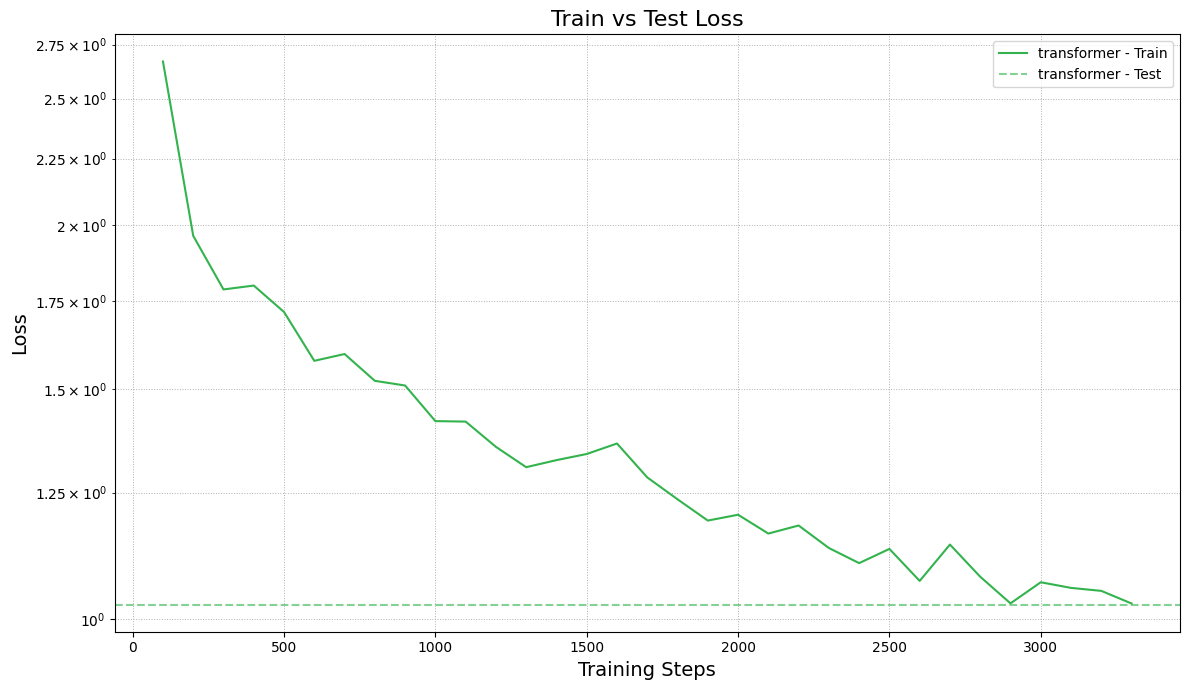

In [ ]:
#XIAODI :1. CHANGE INCREASED EMBEDDING SIZE (TO 2048), TRAIN/TEST SPLIT
#        2. Reduce Embedding size to 512
#        3. redo 1024 embedding size


# starter code by matus & o1-pro

# starter code by matus & o1-pro
# -- IMPLEMENTATIONS ADDED BY US --
import argparse
import time
import random
import math
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from datasets import load_dataset
import tiktoken

################################################################################
# 1. Command-line arg parsing
################################################################################

def parse_args():#Parses command-line arguments (e.g., embedding size, block size, prompt, number of heads, model layers).
#Returns an object containing all configuration settings for the training run.
    parser = argparse.ArgumentParser(description="Train multiple k-gram or sequence-based models on TinyStories and/or custom text files.")
    parser.add_argument("--input_files", nargs="*", default=None)
    parser.add_argument("--tinystories_weight", type=float, default=0.5)
    parser.add_argument("--max_steps_per_epoch", type=int, default=None)
    parser.add_argument("--num_inner_mlp_layers", type=int, default=1)
    parser.add_argument("--monosemantic_enabled", action="store_true")
    parser.set_defaults(monosemantic_enabled=False)
    parser.add_argument("--kgram_k", type=int, default=3)
    parser.add_argument("--kgram_chunk_size", type=int, default=1)
    parser.add_argument("--block_size", type=int, default=1024)
    parser.add_argument("--embed_size", type=int, default=512)
    parser.add_argument("--prompt", type=str, default="Once upon a")
    parser.add_argument("--n_heads", type=int, default= 8)
    parser.add_argument("--n_blocks", type=int, default=8)
    parser.add_argument("--device_id", type=str, default="cuda:0")
    args = parser.parse_args()
    return args

################################################################################
# 2. Data handling
################################################################################

class MixedSequenceDataset(torch.utils.data.Dataset):
    def __init__(self, tinystories_seqs, other_seqs, p_tiny: float):
      #Initializes the dataset, which combines sequences from the TinyStories dataset and any custom input files.
      # calculates the total length and stores the probability (p_tiny) for sampling from TinyStories.
        super().__init__()
        self.tinystories_seqs = tinystories_seqs
        self.other_seqs = other_seqs
        self.p_tiny = p_tiny
        self.has_tinystories = (len(self.tinystories_seqs) > 0)
        self.has_other = (len(self.other_seqs) > 0)
        self.total_length = len(self.tinystories_seqs) + len(self.other_seqs)
        if self.total_length == 0:
            raise ValueError("No data found! Both TinyStories and other sets are empty.")

    def __len__(self):#Returns the total number of sequences available in the combined dataset.
        return self.total_length

    def __getitem__(self, idx):
      #Samples and returns a single token sequence as a PyTorch tensor.
#It uses random selection, weighted by p_tiny, to choose between a TinyStories sequence and a custom input sequence.
        r = random.random()
        if self.has_tinystories and self.has_other:
            if r < self.p_tiny:
                i = random.randint(0, len(self.tinystories_seqs) - 1)
                seq = self.tinystories_seqs[i]
            else:
                i = random.randint(0, len(self.other_seqs) - 1)
                seq = self.other_seqs[i]
        elif self.has_tinystories:
            i = random.randint(0, len(self.tinystories_seqs) - 1)
            seq = self.tinystories_seqs[i]
        else:
            i = random.randint(0, len(self.other_seqs) - 1)
            seq = self.other_seqs[i]
        return torch.tensor(seq, dtype=torch.long)

def seq_collate_fn(batch):
  #A collate function used by the PyTorch DataLoader.
#Since input sequences have varying lengths, this function finds the maximum length.
#It pads all sequences with zeros to that maximum length, returning a single padded tensor.
    max_len = max(len(seq) for seq in batch)
    batch_size = len(batch)
    padded = torch.zeros(max_len, batch_size, dtype=torch.long)
    for i, seq in enumerate(batch):
        seq_len = seq.size(0)
        padded[:seq_len, i] = seq
    return padded

################################################################################
# 3. K-gram MLP
################################################################################

def compute_next_token_loss(logits, tokens):
  #Calculates the standard language modeling loss (Cross-Entropy Loss).
#It compares the model's predicted logits for token $t+1$ with the ground-truth token $t+1$.
#This effectively shifts the tokens to align predictions with targets.
    seq_len, batch_size, vocab_size = logits.shape
    if seq_len < 2:
        return torch.tensor(0.0, device=logits.device, requires_grad=True)
    preds = logits[:-1, :, :]
    gold = tokens[1:, :]
    preds = preds.reshape(-1, vocab_size)
    gold = gold.reshape(-1)
    return F.cross_entropy(preds, gold)

class KGramMLPSeqModel(nn.Module):
    def __init__(self, vocab_size, k=3, embed_size=1024, num_inner_layers=1, chunk_size=1):
      #Initializes the K-Gram MLP model.
#This model predicts the next token based on a fixed window of the previous k tokens.
#It sets up the sequential MLP layers.
        super().__init__()
        self.k = k
        self.vocab_size = vocab_size
        self.embed_size = embed_size
        self.num_inner_layers = num_inner_layers
        self.chunk_size = chunk_size
        input_dim = k * vocab_size
        hidden_dim = embed_size
        layers = []
        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(nn.SiLU())
        for _ in range(num_inner_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.SiLU())
        layers.append(nn.Linear(hidden_dim, vocab_size))
        self.net = nn.Sequential(*layers)

    def forward(self, tokens_seq):
       #Performs the forward pass by constructing a context window of size $k$ for every token.
#It converts this context into a large, concatenated one-hot input vector.
#The vector is passed through the multi-layer perceptron (MLP) to get the next-token logits.
        """
        Fully vectorized K-gram forward pass.
        tokens_seq: (seq_len, batch)
        returns logits: (seq_len, batch, vocab_size)
        """
        seq_len, batch = tokens_seq.shape
        device = tokens_seq.device

        # Build index matrix:
        # each row t contains [t-(k-1), ..., t]
        idx = torch.arange(seq_len, device=device).unsqueeze(1) - torch.arange(self.k-1, -1, -1, device=device)
        # shape: (seq_len, k)

        # Mark padding positions
        pad_mask = idx < 0
        idx = idx.clamp(min=0)

        # Gather contexts from tokens_seq
        # tokens_seq: (seq_len, batch)
        contexts = tokens_seq[idx, :]   # (seq_len, k, batch)
        contexts = contexts.permute(0, 2, 1)  # -> (seq_len, batch, k)

        # Replace pad positions with 0
        contexts[pad_mask.unsqueeze(1).expand_as(contexts)] = 0

        # One-hot encode all at once
        one_hot = F.one_hot(contexts, num_classes=self.vocab_size).float()
        flat = one_hot.flatten(-2, -1)  # (seq_len, batch, k*vocab)

        # Run through MLP in ONE pass
        logits = self.net(flat)

        return logits



################################################################################
# 4. LSTM
################################################################################

class LSTMSeqModel(nn.Module):
    def __init__(self, vocab_size, embed_size=1024, hidden_size=1024):
      #Initializes the standard Long Short-Term Memory (LSTM) model.
#This includes the token embedding layer and the LSTM recurrent layer.
#A final linear layer projects the hidden state back to the vocabulary size (logits).
        super().__init__()
        self.vocab_size = vocab_size
        self.embed_size = embed_size
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(embed_size, hidden_size, batch_first=False)
        self.linear = nn.Linear(hidden_size, vocab_size)

    def forward(self, tokens_seq):
      #Performs the forward pass: embeds input tokens.
#Passes the embeddings through the LSTM layer.
#Produces the next-token logits via a final linear layer.
        emb = self.embedding(tokens_seq)
        self.lstm.flatten_parameters()
        out, _ = self.lstm(emb)
        logits = self.linear(out)
        return logits

################################################################################
# 5. Transformer + RMSNorm
################################################################################

class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-5):
      #Initializes the RMS Normalization layer.
#This is an alternative to LayerNorm often used in modern Transformer architectures like LLama.
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))
    def forward(self, x):
      #Applies the RMS normalization process.
#This involves dividing the input by its Root Mean Square.
#Multiplies the result by a learned weight parameter.
        rms = torch.sqrt(torch.mean(x**2, dim=-1, keepdim=True) + self.eps)
        return (x / rms) * self.weight

class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, mlp_ratio=4):
      #Initializes a single Transformer block.
#It consists of a multi-head self-attention layer and a feed-forward MLP.
#Each sub-layer is preceded by RMS Normalization.
        super().__init__()
        self.norm1 = RMSNorm(d_model)
        self.attn = nn.MultiheadAttention(embed_dim=d_model, num_heads=n_heads, batch_first=False)
        self.norm2 = RMSNorm(d_model)
        hidden_dim = d_model * mlp_ratio
        self.mlp = nn.Sequential(
            nn.Linear(d_model, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, d_model),
        )

    def forward(self, x, mask=None):
      #Executes the forward pass through a single block.
#Applies RMSNorm and Attention (with a mask), followed by a residual connection.
#Then applies another RMSNorm and the MLP.
#Concludes with a final residual connection.
        normed_x = self.norm1(x)
        attn_output, _ = self.attn(normed_x, normed_x, normed_x, attn_mask=mask, is_causal=False)
        x = x + attn_output
        x = x + self.mlp(self.norm2(x))
        return x

class TransformerModel(nn.Module):
    def __init__(self, vocab_size=50257, d_model=1024, n_heads=2, n_blocks=4):
      #Initializes the complete Transformer model.
#This includes the token embedding and a stack of TransformerBlocks.
#It uses a final RMSNorm layer and the unembedding linear layer.
        super().__init__()
        self.vocab_size = vocab_size
        self.tok_embed = nn.Embedding(vocab_size, d_model)
        self.blocks = nn.ModuleList([TransformerBlock(d_model, n_heads) for _ in range(n_blocks)])
        self.norm = RMSNorm(d_model)
        self.unembed = nn.Linear(d_model, vocab_size)
        self.causal_mask = None

    def _prepare_causal_mask(self, seq_len, device):
      #Creates the causal (look-ahead) mask, which is an upper-triangular matrix.
#This mask is used in the self-attention mechanism.
#It ensures a token only attends to previous tokens in the sequence.
        if self.causal_mask is not None and self.causal_mask.size(0) >= seq_len:
            return self.causal_mask[:seq_len, :seq_len].to(device)
        mask = torch.full((seq_len, seq_len), float('-inf'), device=device)
        mask = torch.triu(mask, diagonal=1)
        self.causal_mask = mask
        return mask

    def forward(self, tokens_seq):
      #Performs the full forward pass, starting with token embedding.
#Applies the stack of Transformer attention blocks.
#Concludes with final normalization and generating vocabulary logits.
        seq_len, batch_size = tokens_seq.shape
        device = tokens_seq.device
        x = self.tok_embed(tokens_seq)
        mask = self._prepare_causal_mask(seq_len, device)
        for block in self.blocks:
            x = block(x, mask)
        x = self.norm(x)
        logits = self.unembed(x)
        return logits

################################################################################
# 6. Sampling + generation
################################################################################

def nucleus_sampling(logits, p=0.95):
  #Implements Top-P (Nucleus) sampling, a technique for generating more diverse and coherent text.
#It filters the vocabulary to only include tokens whose cumulative probability exceeds a threshold p.
#The function then samples from the remaining subset.
    if p >= 1.0:
        probs = F.softmax(logits, dim=-1)
        next_token_idx = torch.multinomial(probs, num_samples=1)
        return next_token_idx.item()
    probs = F.softmax(logits, dim=-1)
    sorted_probs, sorted_indices = torch.sort(probs, descending=True)
    cum_probs = torch.cumsum(sorted_probs, dim=-1)
    sorted_probs_to_remove = cum_probs > p
    sorted_probs_to_remove[..., 1:] = sorted_probs_to_remove[..., :-1].clone()
    sorted_probs_to_remove[..., 0] = False
    probs_to_keep = torch.zeros_like(sorted_probs)
    probs_to_keep[~sorted_probs_to_remove] = sorted_probs[~sorted_probs_to_remove]
    if probs_to_keep.sum() < 1e-6:
        return sorted_indices[0].item()
    probs_to_keep = probs_to_keep / probs_to_keep.sum()
    next_token_sorted_idx = torch.multinomial(probs_to_keep, num_samples=1)
    next_token_idx = sorted_indices[next_token_sorted_idx]
    return next_token_idx.item()

def generate_text(model, enc, init_text, max_new_tokens=30, device="cpu", top_p=None,
                  monosemantic_info=None, do_monosemantic=False):
  #Handles the autoregressive text generation process.
#It feeds the prompt tokens into the model and uses the model's logits to predict the next token (greedy or Top-P sampling).
#It appends the prediction to the sequence and repeats for a set number of steps.
    was_training = model.training
    model.eval()
    with torch.no_grad():
        context_tokens = enc.encode(init_text)
        generated_tokens = []
        for step_i in range(max_new_tokens):
            seq_tensor = torch.tensor(context_tokens, dtype=torch.long, device=device).unsqueeze(1)
            logits_seq = model(seq_tensor)
            next_logits = logits_seq[-1, 0, :]
            if top_p is None:
                chosen_token = torch.argmax(next_logits).item()
            else:
                chosen_token = nucleus_sampling(next_logits, p=top_p)
            context_tokens.append(chosen_token)
            generated_tokens.append((chosen_token, []))
    model.train(was_training)
    final_text = enc.decode(context_tokens)
    prefix_text = init_text
    annotated_strs = [prefix_text]
    for (tid, neighs) in generated_tokens:
        token_str = enc.decode([tid])
        annotated_strs.append(token_str)
    annotated_text = "".join(annotated_strs)
    return final_text, annotated_text

################################################################################
# 7. Training
################################################################################

def train_one_model(model, loader, epochs, model_name, device, lr=1e-3,
                    log_steps=100, sample_interval=30, max_steps_per_epoch=None,
                    enc=None, monosemantic_info=None, prompt="Once upon a"):
  #Manages the main training loop for a single model.
#It handles batch iteration, forward pass, loss calculation, backpropagation, and optimizer steps.
#Includes periodic logging of the average training loss.
    optimizer = optim.Adam(model.parameters(), lr=lr, fused=isinstance(model, TransformerModel))
    start_time = time.time()
    next_sample_time = start_time
    global_step = 0
    avg_losses_list = []

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        partial_loss = 0.0
        partial_count = 0
        step_in_epoch = 0
        for batch_idx, batch_tokens in enumerate(loader, start=1):
            step_in_epoch += 1
            global_step += 1
            batch_tokens = batch_tokens.to(device)
            logits = model(batch_tokens)
            loss = compute_next_token_loss(logits, batch_tokens)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            partial_loss += loss.item()
            partial_count += 1
            if batch_idx % log_steps == 0:
                avg_part_loss = partial_loss / partial_count
                avg_losses_list.append(avg_part_loss)
                print(f"[{model_name}] Epoch {epoch}/{epochs}, Step {batch_idx}/{len(loader)} "
                      f"Partial Avg Loss: {avg_part_loss:.4f}")
                partial_loss = 0.0
                partial_count = 0
            current_time = time.time()
            if max_steps_per_epoch is not None and step_in_epoch >= max_steps_per_epoch:
                break
        avg_loss = total_loss / step_in_epoch
        print(f"[{model_name}] End of Epoch {epoch} Avg Loss: {avg_loss:.4f}")
    return avg_losses_list

# *** OUR CHANGE ***
# sets the model to evaluation mode (model.eval()) and disables gradient calculation (torch.no_grad()).
# also iterates over the provided data loader (intended for the test set), calculates the compute_next_token_loss, and returns the average test loss.
def evaluate_model(model, loader, device):
  #Performs a single pass over the test dataset.
#Calculates the model's average loss on unseen data.
#This provides a measure of generalization ability.
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for batch_tokens in loader:
            batch_tokens = batch_tokens.to(device)
            logits = model(batch_tokens)
            loss = compute_next_token_loss(logits, batch_tokens)
            total_loss += loss.item()
    avg_loss = total_loss / len(loader)
    return avg_loss
# *** END OUR CHANGE ***

# *** OUR CHANGE ***
# imports matplotlib.pyplot and It creates a plot showing the training loss curve for each model against the training steps.
# adds a dashed horizontal line for the final test loss of each model.
# saves the combined plot to a file named training_and_test_loss_plot.png.
import matplotlib.pyplot as plt

def plot_train_test_loss_curves(train_losses, test_losses, log_interval):
  #(Added Functionality) Visualizes the training loss over time.
#It compares the training loss against the final test loss for all trained models.
#The resulting graph is saved as a PNG file.
    """
    Plots training and test loss curves for multiple models on the same figure.

    Args:
        train_losses (dict): {model_name: [list of train loss values]}
        test_losses (dict): {model_name: scalar test loss}
        log_interval (int): Number of steps between logging losses
    """
    plt.figure(figsize=(12, 7))

    # Define consistent colors for each model
    colors = {
        "kgram_mlp_seq": (0.2, 0.4, 0.8),   # blue
        "lstm_seq": (0.9, 0.5, 0.1),        # orange
        "transformer": (0.2, 0.7, 0.3),     # green
    }

    for model_name in train_losses.keys():
        color = colors.get(model_name, (0.1, 0.7, 0.3))
        steps = [i * log_interval for i in range(1, len(train_losses[model_name]) + 1)]

        # Plot training curve
        plt.plot(
            steps,
            train_losses[model_name],
            label=f"{model_name} - Train",
            color=color
        )

        # Plot test loss as dashed horizontal line
        if model_name in test_losses:
            plt.axhline(
                y=test_losses[model_name],
                color=color,
                linestyle='--',
                alpha=0.6,
                label=f"{model_name} - Test"
            )

    plt.title("Train vs Test Loss", fontsize=16)
    plt.xlabel("Training Steps", fontsize=14)
    plt.ylabel("Loss", fontsize=14)
    plt.legend()
    plt.grid(True, which='both', linestyle=':', linewidth=0.7)
    plt.yscale('log')  # useful when loss spans several orders of magnitude
    plt.tight_layout()
    plt.savefig("training_and_test_loss_plot.png", dpi=300)
    print("Saved combined train/test loss plot to 'training_and_test_loss_plot.png'")
# *** END OUR CHANGE ***


################################################################################
# 8. Main
################################################################################

def main():
  #The primary entry point of the script. It orchestrates the entire process.
#It loads arguments, initializes the device, loads and tokenizes the data, and splits it into train/test sets.
#It instantiates the selected models (currently only transformer), initiates training, performs final evaluation, and saves the loss plot.



    args = parse_args()
    k = args.kgram_k
    chunk_size = args.kgram_chunk_size
    embed_size = args.embed_size
    batch_size = 16
    num_epochs = 3
    learning_rate = 1e-3
    block_size = args.block_size
    train_subset_size = 20000
    log_interval_steps = 100
    sample_interval_seconds = 30
    max_steps_per_epoch = args.max_steps_per_epoch
    num_inner_layers = args.num_inner_mlp_layers
    requested_device_id = args.device_id
    if requested_device_id.startswith("cuda") and not torch.cuda.is_available():
        device = torch.device("cpu")
    else:
        try:
            device = torch.device(requested_device_id)
            _ = torch.tensor([1]).to(device)
        except Exception:
            device = torch.device("cpu")

    print(f"Using device: {device}")

    tinystories_seqs = []
    other_seqs = []
    if args.tinystories_weight > 0.0:
        try:
            dataset = load_dataset("roneneldan/TinyStories", split="train")
            dataset = dataset.select(range(train_subset_size))
        except Exception:
            dataset = None
    else:
        dataset = None

    enc = tiktoken.get_encoding("gpt2")
    vocab_size = enc.n_vocab

    if dataset is not None:
        for sample in dataset:
            text = sample['text']
            tokens = enc.encode(text)
            tokens = tokens[:block_size]
            if len(tokens) > 0:
                tinystories_seqs.append(tokens)

    if args.input_files:
        for filepath in args.input_files:
            with open(filepath, "r", encoding="utf-8") as f:
                lines = f.readlines()
            for line in lines:
                line = line.strip()
                if not line:
                    continue
                tokens = enc.encode(line)
                tokens = tokens[:block_size]
                if len(tokens) > 0:
                    other_seqs.append(tokens)

    if len(tinystories_seqs) == 0 and len(other_seqs) == 0:
        print("No data loaded, exiting.")
        return

    combined_dataset = MixedSequenceDataset(tinystories_seqs, other_seqs, args.tinystories_weight)

    # *** OUR CHANGE ***
    # calculates a 90% training size and a 10% test size.
    # uses torch.utils.data.random_split to divide the data into train_set and test_set.
    # creates a test_loader to handle batching and loading of the test data for evaluation.
    train_size = int(0.9 * len(combined_dataset))
    test_size = len(combined_dataset) - train_size
    train_set, test_set = torch.utils.data.random_split(combined_dataset, [train_size, test_size])
    train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True, collate_fn=seq_collate_fn)
    test_loader = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=False, collate_fn=seq_collate_fn)
    # *** END OUR CHANGE ***
    # =MODELS ===
    kgram_model = KGramMLPSeqModel(
        vocab_size=vocab_size,
        k=k,
        embed_size=embed_size,
        num_inner_layers=num_inner_layers,
        chunk_size=chunk_size
    ).to(device)

    lstm_model = LSTMSeqModel(
        vocab_size=vocab_size,
        embed_size=embed_size,
        hidden_size=embed_size
    ).to(device)

    transformer = TransformerModel(
        vocab_size=vocab_size,
        d_model=embed_size,
        n_heads=args.n_heads,
        n_blocks=args.n_blocks
    ).to(device)

    models = {
        #"kgram_mlp_seq": kgram_model,
       # "lstm_seq": lstm_model,
        "transformer": transformer,
    }

    # *** OUR CHANGE ***
    #Initializes dictionaries to store the training loss history and final test loss for all models.
    all_train_losses = {}
    all_test_losses = {}
    # *** END OUR CHANGE ***

    # === trian validate ==
    for model_name, model in models.items():
        print(f"\n=== Training model: {model_name} ===")
        params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"[{model_name}] Parameters: {params:,}")

        current_lr = 1e-3 if model_name == "transformer" else learning_rate #I increased the LR (old:3e-4)
        print(f"[{model_name}] Learning rate: {current_lr}")

        train_losses = train_one_model(
            model=model,
            loader=train_loader,
            epochs=num_epochs,
            model_name=model_name,
            device=device,
            lr=current_lr,
            log_steps=log_interval_steps,
            sample_interval=sample_interval_seconds,
            max_steps_per_epoch=max_steps_per_epoch,
            enc=enc,
            prompt=args.prompt
        )
        all_train_losses[model_name] = train_losses

        # *** OUR CHANGE ***
        #Calls the new evaluate_model function for each trained model using the test_loader.
        #Stores the final test loss and prints it to the console.
        test_loss = evaluate_model(model, test_loader, device)
        all_test_losses[model_name] = test_loss
        print(f"[{model_name}] Final Test Loss: {test_loss:.4f}")
        # *** END OUR CHANGE ***

        # GENERATING TEXT
        with torch.no_grad():
            text_greedy, _ = generate_text(model, enc, args.prompt, max_new_tokens=20, device=device, top_p=None)
            text_topp, _ = generate_text(model, enc, args.prompt, max_new_tokens=20, device=device, top_p=0.95)
            text_topp1, _ = generate_text(model, enc, args.prompt, max_new_tokens=20, device=device, top_p=1.0)

        print(f"\n[{model_name}] Final sample (greedy):\n{text_greedy}")
        print(f"[{model_name}] Final sample (top-p=0.95):\n{text_topp}")
        print(f"[{model_name}] Final sample (top-p=1.0):\n{text_topp1}")
        print("--------------------------------------------------")

        # TEST-TIME SEARCH EXTENSION =
        print("\n[Test-Time Search] Multiple Candidates:")
        search_results = simple_search(model, enc, args.prompt, device=device)

        for i, s in enumerate(search_results):
          print(f"Candidate {i+1}: {s}\n")

    # *** OUR CHANGE ***
    #Calls the plot_train_test_loss_curves function after all models have been trained and evaluated, generating the final loss comparison graph.
    plot_train_test_loss_curves(all_train_losses, all_test_losses, log_interval_steps)
    # *** END OUR CHANGE ***
    # ... inside main(), after plot_train_test_loss_curves call ...

    # ==========================================
    # === START DPO ALIGNMENT STEP ===
    # ==========================================

    # We only apply DPO to the Transformer model as requested
    if "transformer" in models:
        print("\n=== Starting DPO (Alignment) Phase for Transformer ===")

        # 1. Create the Reference Model (Frozen Copy)
        # Deepcopy the model currently in GPU memory
        ref_model = copy.deepcopy(transformer)
        ref_model.to(device)
        ref_model.eval()
        # Freeze parameters of reference model to save memory/computation
        for param in ref_model.parameters():
            param.requires_grad = False

        # 2. Prepare Preference Data
        # Since we don't have an external preference dataset, we create a synthetic one
        # using the TinyStories data we already loaded.
        # Ideally, 'chosen' is high quality and 'rejected' is low quality.
        dpo_dataset = PreferenceDataset(tinystories_seqs[:2000]) # Use subset for speed
        dpo_loader = torch.utils.data.DataLoader(
            dpo_dataset,
            batch_size=8, # Smaller batch size for DPO due to double forward pass
            shuffle=True,
            collate_fn=dpo_collate_fn
        )

        # 3. Run DPO Training
        # We use a much smaller learning rate (1e-5 or 5e-6) to avoid breaking the model
        train_dpo(transformer, ref_model, dpo_loader, epochs=1, device=device, lr=5e-6, beta=0.1)

        # 4. Evaluate Post-DPO
        print("\n[DPO] Generating text after alignment:")
        with torch.no_grad():
             text_dpo, _ = generate_text(transformer, enc, args.prompt, max_new_tokens=30, device=device)
        print(f"[Post-DPO] Sample: {text_dpo}")

        # Clean up ref model to free memory
        del ref_model
        torch.cuda.empty_cache() if torch.cuda.is_available() else None

    # ==========================================
    # === END DPO ALIGNMENT STEP ===
    # ==========================================

    # Finally, let's share how I'm feeling:
    print("\n*** I'm feeling great today! Hope you're well, too. ***")

if __name__ == "__main__":
    main()